This notebook fits by-cre models on the shendure data & demonstrates that estimated nb parameters track closely with UMI means, as expected.

The matrix-creation and fitting code is independent of the main scMPRA package, since its this analysis that informed the package code.

# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#imports
import pandas as pd
import numpy as np
import time
import pickle
from formulaic import Formula
import seaborn as sns
import matplotlib.pyplot as plt

from tensorzinb.tensorzinb import TensorZINB
import scMPRAforge as scm

2025-07-23 14:33:05.694079: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-23 14:33:05.698330: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-07-23 14:33:05.698348: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


In [3]:
#create dask cluster

from dask_jobqueue import SLURMCluster
from dask.distributed import Client

cluster=SLURMCluster(
    cores=4,#cores per slurm job
    memory="16G",#memory per slurm job
    processes=4,#dask workers per slurm job
    job_extra_directives=["-p ycga", 
        f"--job-name=simclust_worker",
        f"--time=4:00:00",
        f"--output=slave_%j.out"]
)

cluster.scale(jobs=4)

client = Client(cluster,
        timeout=f"{5*60}s",   # Client <-> scheduler timeout 
        heartbeat_interval="20s"  # Worker heartbeat interval
    )

#from dask.distributed import Client, LocalCluster
#cluster=LocalCluster(memory_limit='8GB')
#client = Client(cluster)

# Describe with an ortho

In [8]:
path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial_v2"

import os
if os.path.isdir(path+"/"+name):
    print("[+] Model found. Loading...")
    primordial=scm.ortho.load(client,path,name)
    shendure=primordial.training_data
else:
    print("[+] Model not found. Creating...")

    #load data
    data_root="/gpfs/gibbs/pi/reilly/tabula_data"
    shendure=scm.scMPRA_data.from_tsv(f"{data_root}/shendure/shendure_counts_grouped.txt")
    shendure.set_negative_controls(["minP","noP"])
    shendure.set_reference_cell("Pluripotent")
    shendure.ortho_filter()

    primordial=scm.ortho()
    primordial.criss_cross(client=client,
                       dat=shendure)
    primordial.extract_params(client)
    primordial.save(path,name)


[+] Model found. Loading...


In [9]:
primordial.by_cell_type_design["NeuroectodermBrain"].result()["nb_formula"]

"umis_mpra_bc ~ C(cre_id, contr.treatment(base='reference'))"

In [10]:
primordial.by_cell_type_design

{'NeuroectodermBrain': <Future: finished, type: dict, key: lambda-0506ccf5ef818e983f5c7c215687ba38>,
 'EpiblastPrimitiveStreak': <Future: finished, type: dict, key: lambda-0ced1b5e8debbaf1448fc3e36c67a951>,
 'SurfaceEctoderm': <Future: finished, type: dict, key: lambda-fe04f34ec67397a628a0f946faa4570f>,
 'Mesoderm': <Future: finished, type: dict, key: lambda-5f6401d1265ebe22663fd57df1676d4e>,
 'reference': <Future: finished, type: dict, key: lambda-ecf64bebbcfb14b65d04203176a1cacb>,
 'Haematoendothelial': <Future: finished, type: dict, key: lambda-4decf0034c9378777cec7e3b7065ff29>,
 'Cardiomyocytes': <Future: finished, type: dict, key: lambda-52be647950fb202507ad0287b0d2c024>,
 'NeuroectodermRostral': <Future: finished, type: dict, key: lambda-0106cf7a95fe8d3978701c813a7f9fbe>,
 'ExEndodermParietal': <Future: finished, type: dict, key: lambda-e13b045aa8b7b71fe0a1ed3e4f3eeb92>,
 'ExEndodermVisceral': <Future: finished, type: dict, key: lambda-22f37269822bd1a693e2dadeb7bacf25>}

In [11]:
primordial.by_cell_type_parameters.keys

['NeuroectodermBrain',
 'EpiblastPrimitiveStreak',
 'SurfaceEctoderm',
 'Mesoderm',
 'reference',
 'Haematoendothelial',
 'Cardiomyocytes',
 'NeuroectodermRostral',
 'ExEndodermParietal',
 'ExEndodermVisceral']

In [12]:
primordial.compute_model_qc()

regression error on Lama1_chr17_7892


# Examine QC metrics

TODO: check the one that failed.

Now that we've generated some QC metrics, let's examine them. First, let's look at the mu min & max : none should be below zero, none should be above 1000.

In [13]:
def minimax(QC):
    x=[]
    for level in QC.keys():
        if QC[level]["success"]:
            x.append(QC[level]["dat"])
    x=pd.concat(x)
    print(f"min {min(x['mu'])}, max {max(x['mu'])}")

print("cre")
minimax(primordial.by_cre_qc)
print("ct")
minimax(primordial.by_cell_qc)

cre
min 0.006072484102915723, max 474.3955867867858
ct
min 0.003765607342565714, max 446.3663477129888


All in the right ballpark!

Now let's look at the correlations.

---
low r Cdk5r1_chr11_12595
low r Lamc1_chr1_12183
low r Lamb1_chr12_2206
nan in Txndc12_chr4_7969
---
[0.990815837849754, 0.9999960403687211, 0.9984233047715513, 0.9987531055920469, 0.997811021128109, 0.9991493806107715, 0.9974825052483511, 0.9999226160040263, 0.9999900584843646, 0.9991253006290407, 0.999993419260603, 0.9974430868648423, 0.9995747430849277, 0.9981699058321086, 0.9978327961900002, 0.9993777340495947, 0.9998072187337383, 0.999900947753999, 0.9739313228530325, 0.9865171740081918, 0.9992760379852181, 0.9987924030604476, 0.9998257729043354, 0.9949603585995653, 0.9928661307429019, 0.998922058192561, 0.999768978663422, 0.9944190202631094, 0.9991121426950129, 0.9999603657539415, 0.9986357265566348, 0.9999993795237245, 0.9999106321738532, 0.9989792631620014, 0.9998891088914603, 0.9999864934767028, 0.99998792881506, 0.9999652507727418, 0.9999997422791703, 0.9980661033312703, 0.9998648214760295, 0.9856513723813832, 0.9979801623332499, 0.9798554678765986, 0.997924573576728, 0.99

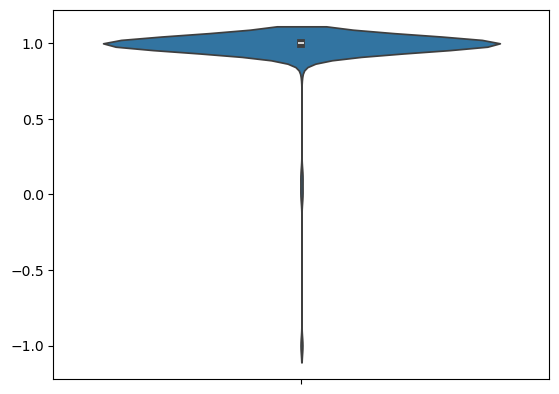

In [14]:
r=[]
for QC in [primordial.by_cre_qc,primordial.by_cell_qc]:
    print("---")
    
    for level in QC.keys():
        if QC[level]["success"]:
            if np.isnan(QC[level]["r_value"]):
                print(f"nan in {level}")
            else:
                if QC[level]["r_value"]<0.8:
                    print(f"low r {level}")
                r.append(QC[level]["r_value"])


sns.violinplot(r)

print(r)
#print(np.mean(r))
#for cell_type in QC:
#    print(f"{cell_type} : r={QC[cell_type]['r_value']}, slope={QC[cell_type]['slope']}")

Correlations generally look pretty good. Let's examine the cases where they aren't.

Notably all of the bad ones are from the set of "by cell-type" models.

I'm going to guess these are low-expressing CREs. Let's take a look.

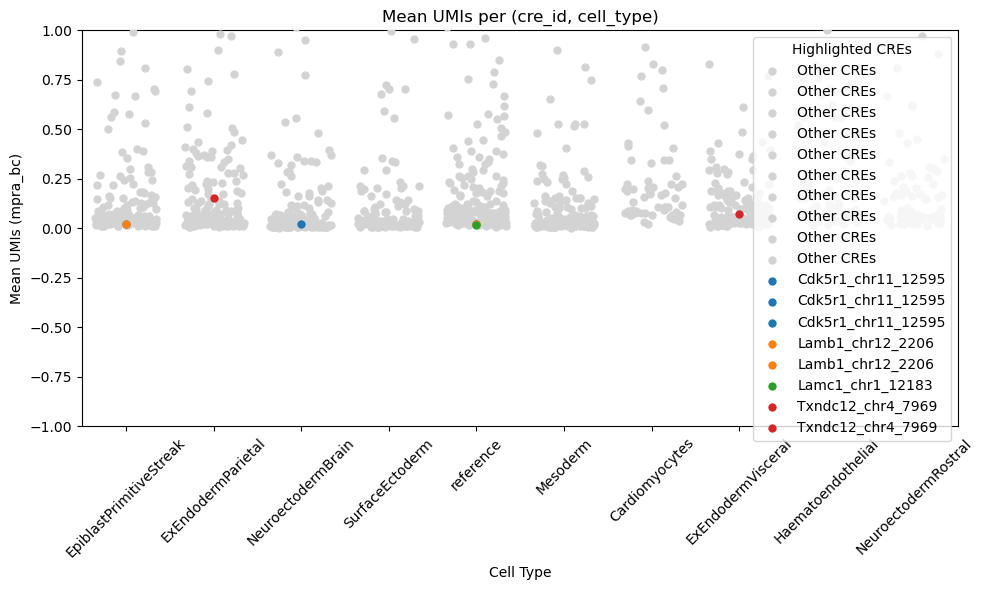

In [16]:
highlighted_cre_ids=["Cdk5r1_chr11_12595","Lamb1_chr12_2206","Lamc1_chr1_12183","Txndc12_chr4_7969"]

grouped = (
    shendure.data
    .groupby(["cre_id", "cell_type"])["umis_mpra_bc"]
    .mean()
    .reset_index()
)

# Split base vs. highlighted
base = grouped[~grouped["cre_id"].isin(highlighted_cre_ids)]
highlighted = grouped[grouped["cre_id"].isin(highlighted_cre_ids)]

# Set up plot
plt.figure(figsize=(10, 6))

# Plot base layer with jitter
sns.stripplot(
    data=base,
    x="cell_type",
    y="umis_mpra_bc",
    color="lightgray",
    jitter=0.35,
    label="Other CREs",
    size=6
)

# Overlay highlighted CREs with jitter and custom color
palette = sns.color_palette("tab10", n_colors=len(highlighted_cre_ids))
for i, cre in enumerate(highlighted_cre_ids):
    sns.stripplot(
        data=highlighted[highlighted["cre_id"] == cre],
        x="cell_type",
        y="umis_mpra_bc",
        color=palette[i],
        jitter=0.35,
        label=cre,
        size=6
    )

# Y-axis and aesthetics
plt.ylim(-1, 1)
plt.xlabel("Cell Type")
plt.ylabel("Mean UMIs (mpra_bc)")
plt.title("Mean UMIs per (cre_id, cell_type)")
plt.xticks(rotation=45)
plt.legend(title="Highlighted CREs")
plt.tight_layout()
plt.show()


In [17]:
primordial.by_cre_qc["Cdk5r1_chr11_12595"]

{'success': True,
 'dat':                                mu  mean(umis_mpra_bc)
 cell_type                                            
 EpiblastPrimitiveStreak  0.045672            0.021552
 NeuroectodermBrain       0.049217            0.023256
 reference                0.051190            0.021467,
 'slope': 0.3348168581585119,
 'intercept': 0.041296343900131066,
 'r_value': 0.12085245152029905,
 'p_value': 0.9228744164591715,
 'std_err': 2.750153659621498}

In [18]:
cluster.close()